#### A. Conduct an Exploratory Data Analysis (EDA) on the dataset. Highlight the main insights and any irregularities you find, and address those anomalies appropriately!

In [1679]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

In [1680]:
df = pd.read_csv("Bangladesh_Crime_Dataset_A.csv")

In [1681]:
df.head(5)

,Unnamed: 0,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,heatindex,season,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime
0,0,7.0,29,wednesday,0,morning,dhaka,dhaka,6.1,10,32,rainy,4931802,3974237,8906039,125,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
1,1,1.0,2,wednesday,0,night,dhaka,dhaka,0.0,10,22,winter,4931802,3974237,8906039,125,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
2,2,1.0,4,tuesday,0,night,dhaka,dhaka,0.0,10,25,winter,4931802,3974237,8906039,125,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
3,3,3.0,9,friday,1,night,dhaka,dhaka,0.0,10,30,hot,4931802,3974237,8906039,125,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
4,4,8.0,34,thursday,0,night,dhaka,dhaka,21.9,9,38,rainy,4931802,3974237,8906039,125,8.42,30551.0,74.6,4289,99,17,60,242,64,murder


It's a good sign that I see nothing wrong with the example first five rows. But, it's clear there's an extra identifier column to show the row index called 'Unnamed: 0'. This will be dropped since it is just an identifier and an unexpected column too. 

In [1682]:
df = df.drop(columns=['Unnamed: 0'])

In [1683]:
df.head(5)

,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,heatindex,season,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime
0,7.0,29,wednesday,0,morning,dhaka,dhaka,6.1,10,32,rainy,4931802,3974237,8906039,125,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
1,1.0,2,wednesday,0,night,dhaka,dhaka,0.0,10,22,winter,4931802,3974237,8906039,125,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
2,1.0,4,tuesday,0,night,dhaka,dhaka,0.0,10,25,winter,4931802,3974237,8906039,125,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
3,3.0,9,friday,1,night,dhaka,dhaka,0.0,10,30,hot,4931802,3974237,8906039,125,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
4,8.0,34,thursday,0,night,dhaka,dhaka,21.9,9,38,rainy,4931802,3974237,8906039,125,8.42,30551.0,74.6,4289,99,17,60,242,64,murder


In [1684]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_month          5917 non-null   float64
 1   incident_week           6574 non-null   int64  
 2   incident_weekday        6574 non-null   object 
 3   weekend                 6574 non-null   int64  
 4   part_of_the_day         6457 non-null   object 
 5   incident_district       6246 non-null   object 
 6   incident_division       6574 non-null   object 
 7   precip                  6574 non-null   float64
 8   visibility              6574 non-null   int64  
 9   heatindex               6574 non-null   int64  
 10  season                  6574 non-null   object 
 11  male_population         6574 non-null   int64  
 12  female_population       6574 non-null   int64  
 13  total_population        6574 non-null   int64  
 14  gender_ration           6574 non-null   

There are a handful amount of missing values on each columns that will definitely need handling during the preprocessing stage since sklearn models can't directly digest these values. Other than that, the data types of each column seems to truly represent the values they hold.

In [1685]:
df.describe(include='object')

,incident_weekday,part_of_the_day,incident_district,incident_division,season,crime
count,6574,6457,6246,6574,6574,6574
unique,7,5,64,192,3,6
top,tuesday,night,dhaka,dhaka,rainy,murder
freq,1010,3179,1115,1806,2850,1518


There's nothing anomalous just based on .describe() on categorical columns.

In [1686]:
df.describe(exclude='object')

,incident_month,incident_week,weekend,precip,visibility,heatindex,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college
count,5917.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6.574000e+03,6.574000e+03,6.574000e+03,6574.000000,6574.000000,6.574000e+03,6246.000000,6574.00000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000
mean,6.210749,25.193946,0.273806,6.187998,9.488287,31.597657,8.936342e+05,7.544586e+05,1.648104e+06,104.429723,4.965023,1.891212e+52,55.742683,1232.03164,42.504411,3.863706,11.762093,75.218893,15.479617
std,3.319075,14.517965,0.445944,11.989998,0.922742,5.502593,1.605205e+06,1.284180e+06,2.889245e+06,10.387173,1.422850,1.354499e+54,12.082504,1245.17044,44.857967,5.883186,19.604510,71.743767,19.721917
min,1.000000,1.000000,0.000000,0.000000,4.000000,15.000000,1.132000e+04,1.124700e+04,2.287100e+04,84.000000,3.580000,5.615431e-61,26.700000,0.00000,0.000000,0.000000,-1.000000,1.000000,0.000000
25%,3.000000,13.000000,0.000000,0.000000,9.000000,27.000000,1.319300e+05,1.339960e+05,2.652760e+05,98.000000,4.110000,9.100000e+02,46.600000,519.00000,5.000000,0.000000,2.000000,30.000000,4.000000
50%,6.000000,25.000000,0.000000,0.800000,10.000000,33.000000,1.872290e+05,1.870170e+05,3.765500e+05,101.000000,4.440000,1.239000e+03,53.900000,818.00000,25.000000,1.000000,3.000000,45.000000,8.000000
75%,9.000000,37.000000,1.000000,7.500000,10.000000,36.000000,3.917070e+05,3.811572e+05,7.757330e+05,109.000000,5.100000,4.318000e+03,67.200000,1125.00000,78.000000,3.000000,6.000000,86.000000,15.000000
max,12.000000,53.000000,1.000000,204.600000,10.000000,43.000000,4.931802e+06,3.974237e+06,8.906039e+06,203.000000,8.420000,1.090315e+56,74.600000,4289.00000,253.000000,17.000000,74.000000,242.000000,64.000000


There's only one invalid or impossible that appears in the police_station column where some of its values go to the negatives. The police_station column means the number of police stations in the area, and counts cannot go below zero. Hence, these negatives will be treated as missing values to represent how they are not possible to exist in the real world.

In [1687]:
df['police_station'] = df['police_station'].mask(df['police_station'] < 0, np.nan)

In [1688]:
df.describe(exclude='object')

,incident_month,incident_week,weekend,precip,visibility,heatindex,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college
count,5917.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6.574000e+03,6.574000e+03,6.574000e+03,6574.000000,6574.000000,6.574000e+03,6246.000000,6574.00000,6574.000000,6574.000000,6573.000000,6574.000000,6574.000000
mean,6.210749,25.193946,0.273806,6.187998,9.488287,31.597657,8.936342e+05,7.544586e+05,1.648104e+06,104.429723,4.965023,1.891212e+52,55.742683,1232.03164,42.504411,3.863706,11.764035,75.218893,15.479617
std,3.319075,14.517965,0.445944,11.989998,0.922742,5.502593,1.605205e+06,1.284180e+06,2.889245e+06,10.387173,1.422850,1.354499e+54,12.082504,1245.17044,44.857967,5.883186,19.605370,71.743767,19.721917
min,1.000000,1.000000,0.000000,0.000000,4.000000,15.000000,1.132000e+04,1.124700e+04,2.287100e+04,84.000000,3.580000,5.615431e-61,26.700000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,3.000000,13.000000,0.000000,0.000000,9.000000,27.000000,1.319300e+05,1.339960e+05,2.652760e+05,98.000000,4.110000,9.100000e+02,46.600000,519.00000,5.000000,0.000000,2.000000,30.000000,4.000000
50%,6.000000,25.000000,0.000000,0.800000,10.000000,33.000000,1.872290e+05,1.870170e+05,3.765500e+05,101.000000,4.440000,1.239000e+03,53.900000,818.00000,25.000000,1.000000,3.000000,45.000000,8.000000
75%,9.000000,37.000000,1.000000,7.500000,10.000000,36.000000,3.917070e+05,3.811572e+05,7.757330e+05,109.000000,5.100000,4.318000e+03,67.200000,1125.00000,78.000000,3.000000,6.000000,86.000000,15.000000
max,12.000000,53.000000,1.000000,204.600000,10.000000,43.000000,4.931802e+06,3.974237e+06,8.906039e+06,203.000000,8.420000,1.090315e+56,74.600000,4289.00000,253.000000,17.000000,74.000000,242.000000,64.000000


# Categorical Checks

In [1689]:
cat_cols = ['incident_month', 'incident_week', 'incident_weekday', 'weekend', 'part_of_the_day', 'incident_district', 'incident_division', 'season', 'crime']
for c in cat_cols:
    print(f"Distinct categories and its percentage for {c}:")
    print(df[c].value_counts(normalize=True, dropna=False), end='\n\n')

Distinct categories and its percentage for incident_month:
incident_month
NaN     0.099939
8.0     0.088074
5.0     0.083207
4.0     0.082294
1.0     0.081685
3.0     0.078947
7.0     0.078339
10.0    0.076514
6.0     0.075601
2.0     0.073471
9.0     0.073167
11.0    0.055978
12.0    0.052784
Name: proportion, dtype: float64

Distinct categories and its percentage for incident_week:
incident_week
16    0.026620
33    0.026316
42    0.024186
22    0.023578
19    0.023274
3     0.022969
6     0.022513
36    0.022513
2     0.022513
34    0.022209
15    0.022209
10    0.022057
35    0.022057
4     0.021752
7     0.021752
31    0.021600
30    0.021296
29    0.021144
26    0.020688
25    0.020688
18    0.020231
11    0.020079
8     0.019623
13    0.019623
37    0.019319
5     0.019319
28    0.019166
21    0.019014
20    0.018862
17    0.018862
43    0.018254
41    0.018102
24    0.017949
1     0.017797
39    0.017797
12    0.017797
40    0.017797
23    0.017645
32    0.017493
38    0.017341

There are two problems that can be found here:
- The **incident_division** column seems to have inconsistent formatting where at the end there seems to be random uppercasing which is very different from the first six instances. Hence, I will be unifying their format into one by lowercasing everything from that column.
- **incident_month**, **Incident_week**, **Incident_weekday**, **part_of_the_day** are supposed to be cyclical features where its highest value is close to the second highest value and also the lowest value. For example: an incident_month of 12 (December) is close to incident_month of 1 (January) since they are only different by one month. To elaborate this relationship to the model, I will need to cyclic encode these columns to ensure that the model recognize this cyclic relationship.

In [1690]:
df['incident_division'] = df['incident_division'].str.lower()

In [1691]:
df['incident_division'].value_counts(normalize=True)

incident_division
dhaka            0.299817
chattogram       0.155765
rajshahi         0.115911
rangpur          0.104046
khulna           0.103590
mymensingh       0.067539
sylhet           0.061758
barisal          0.060694
  dhaka          0.011409
  chattogram     0.005628
  rajshahi       0.003042
  rangpur        0.002890
  sylhet         0.002738
  khulna         0.002434
  barisal        0.001369
  mymensingh     0.000761
gazipur          0.000608
Name: proportion, dtype: float64

Now, the problem is that some of them has a few extra whitespaces which makes them inconsistent. I would need to trim them up so that they can become one category.

In [1692]:
df['incident_division'] = df['incident_division'].str.strip()

In [1693]:
df['incident_division'].value_counts(normalize=True)

incident_division
dhaka         0.311226
chattogram    0.161393
rajshahi      0.118953
rangpur       0.106936
khulna        0.106024
mymensingh    0.068299
sylhet        0.064497
barisal       0.062063
gazipur       0.000608
Name: proportion, dtype: float64

In [1694]:
print("The percentage of missing values of each column:")
df.isna().mean()

The percentage of missing values of each column:


incident_month            0.099939
incident_week             0.000000
incident_weekday          0.000000
weekend                   0.000000
part_of_the_day           0.017797
incident_district         0.049894
incident_division         0.000000
precip                    0.000000
visibility                0.000000
heatindex                 0.000000
season                    0.000000
male_population           0.000000
female_population         0.000000
total_population          0.000000
gender_ration             0.000000
average_household_size    0.000000
density_per_kmsq          0.000000
literacy_rate             0.049894
religious_institution     0.000000
playground                0.000000
park                      0.000000
police_station            0.000152
school                    0.000000
college                   0.000000
crime                     0.000000
dtype: float64

In [1695]:
df['incident_month'].value_counts(dropna=False)

incident_month
NaN     657
8.0     579
5.0     547
4.0     541
1.0     537
3.0     519
7.0     515
10.0    503
6.0     497
2.0     483
9.0     481
11.0    368
12.0    347
Name: count, dtype: int64

Since incident_month and part_of_the_day have missing values, its derived columns would have missing values as well. And because clustering tasks don't need to do train-test splitting, I will immediately impute the missing values here using the mode of this column.

In [1696]:
mode_month = df['incident_month'].mode()[0]
df['incident_month'] = df['incident_month'].fillna(mode_month)

In [1697]:
df['month_sin'] = np.sin(2 * np.pi * df['incident_month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['incident_month']/12)

In [1698]:
df['week_sin'] = np.sin(2 * np.pi * df['incident_week'] / 53)
df['week_cos'] = np.cos(2 * np.pi * df['incident_week'] / 53)

In [1699]:
weekday_map = {'monday':0,'tuesday':1,'wednesday':2,'thursday':3,'friday':4,'saturday':5,'sunday':6}
df['weekday_num'] = df['incident_weekday'].map(weekday_map)
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday_num']/7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday_num']/7)

In [1700]:
mode_part = df['part_of_the_day'].mode()[0]
df['part_of_the_day'] = df['part_of_the_day'].fillna(mode_part)

In [1701]:
part_of_day_map = { 'night': 0, 'morning': 1, 'noon': 2, 'afternoon': 3, 'evening': 4 }
df['part_of_day_num'] = df['part_of_the_day'].map(part_of_day_map)
df['part_sin'] = np.sin(2 * np.pi * df['part_of_day_num'] / 5)
df['part_cos'] = np.cos(2 * np.pi * df['part_of_day_num'] / 5)

In [1702]:
cat_cols = ['weekend', 'incident_district', 'incident_division', 'season', 'crime']
for c in cat_cols:
    print(f"Distinct categories and its percentage for {c}:")
    print(df[c].value_counts(normalize=True, ), end='\n\n')

Distinct categories and its percentage for weekend:
weekend
0    0.726194
1    0.273806
Name: proportion, dtype: float64

Distinct categories and its percentage for incident_district:
incident_district
dhaka              0.178514
chattogram         0.074288
mymensingh         0.040026
jashore            0.038745
dinajpur           0.031220
narayanganj        0.026737
bogura             0.026257
gazipur            0.025937
pabna              0.025776
tangail            0.024175
sylhet             0.023535
rajshahi           0.021454
brahmanbaria       0.019853
habiganj           0.018732
rangpur            0.017451
patuakhali         0.017291
jamalpur           0.016330
moulvibazar        0.016170
faridpur           0.015530
pirojpur           0.014890
lalmonirhat        0.014890
thakurgaon         0.013769
joypurhat          0.013128
barisal            0.012648
jhenaidah          0.012168
bandarban          0.012168
sirajganj          0.011687
noakhali           0.011687
gaibandha     

# Numerical Checks

In [1703]:
num_cols = ['precip', 'visibility', 'heatindex', 'male_population', 'female_population', 'total_population', 'gender_ration', 'average_household_size', 'density_per_kmsq', 'literacy_rate', 'religious_institution', 'playground', 'park', 'police_station', 'school', 'college']
for col in num_cols:
    invalid_mask = (pd.to_numeric(df[col], errors="coerce").isna() & df[col].notna())

    unique_invalids = df.loc[invalid_mask, col].unique()

    print(f"First five unique invalid values inside {col}:")
    print(unique_invalids[:5])
    print("-" * 40)

First five unique invalid values inside precip:
[]
----------------------------------------
First five unique invalid values inside visibility:
[]
----------------------------------------
First five unique invalid values inside heatindex:
[]
----------------------------------------
First five unique invalid values inside male_population:
[]
----------------------------------------
First five unique invalid values inside female_population:
[]
----------------------------------------
First five unique invalid values inside total_population:
[]
----------------------------------------
First five unique invalid values inside gender_ration:
[]
----------------------------------------
First five unique invalid values inside average_household_size:
[]
----------------------------------------
First five unique invalid values inside density_per_kmsq:
[]
----------------------------------------
First five unique invalid values inside literacy_rate:
[]
----------------------------------------
Fir

There are no invalid values inside the numerical columns, so we're good for this one.

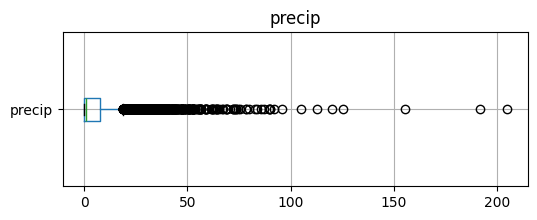

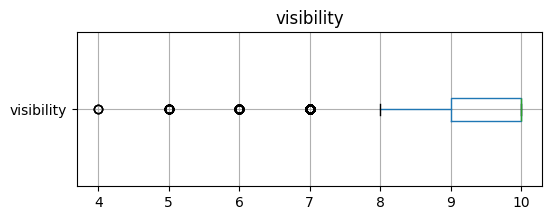

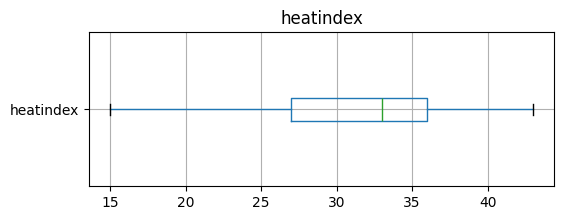

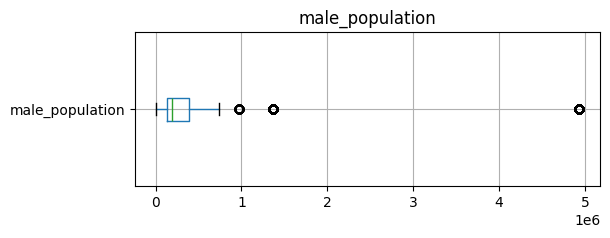

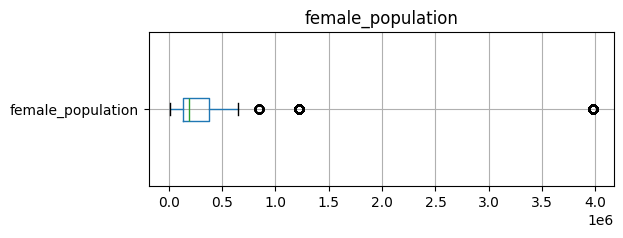

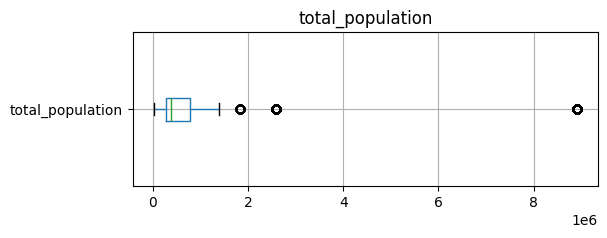

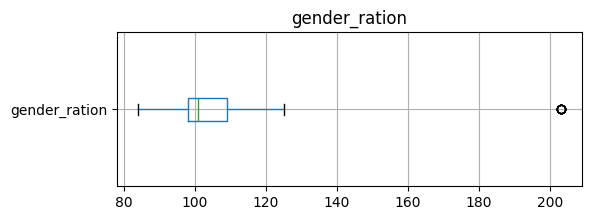

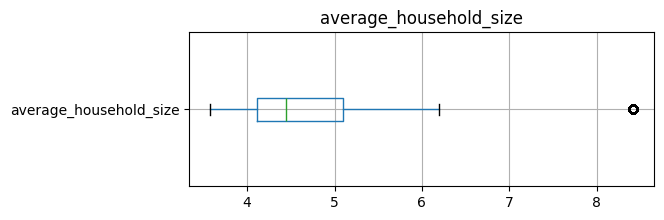

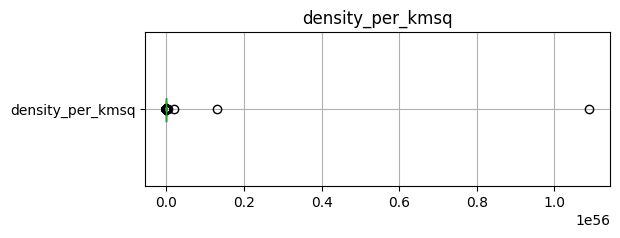

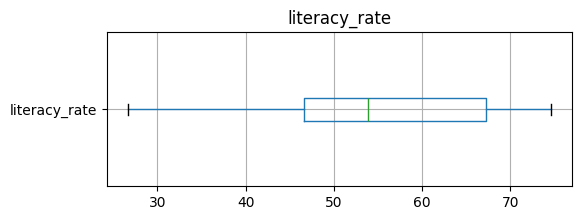

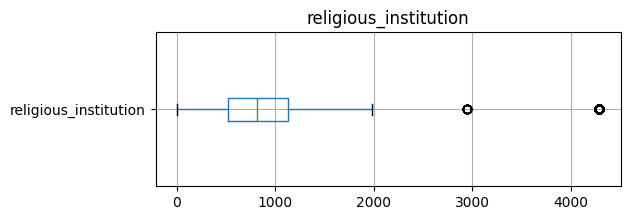

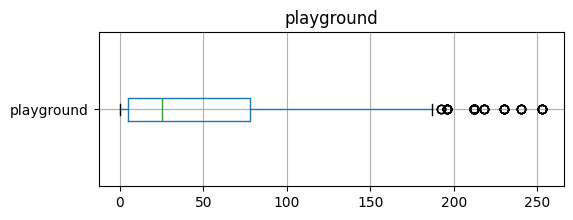

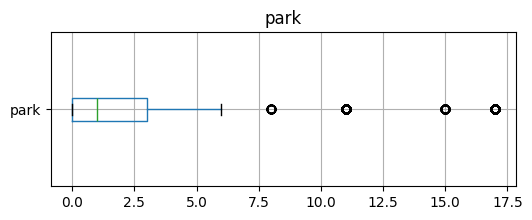

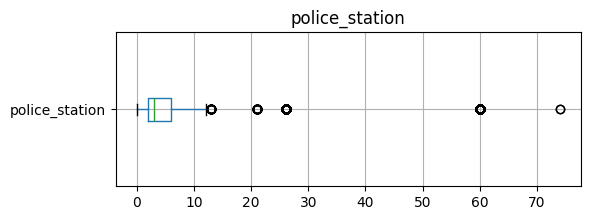

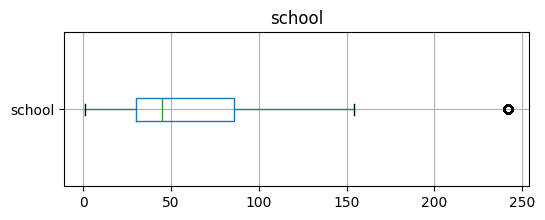

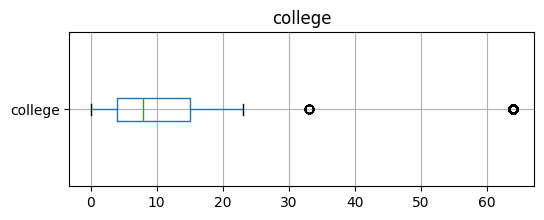

,incident_month,incident_week,weekend,precip,visibility,heatindex,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,month_sin,month_cos,week_sin,week_cos,weekday_num,weekday_sin,weekday_cos,part_of_day_num,part_sin,part_cos
min,1.0,1,0,0.0,4,15,11320,11247,22871,84,3.58,5.615431e-61,26.7,0,0,0,0.0,1,0,-1.0,-1.0,-0.999561,-0.998244,0,-0.974928,-0.900969,0,-0.951057,-0.809017
max,12.0,53,1,204.6,10,43,4931802,3974237,8906039,203,8.42,1.090315e+56,74.6,4289,253,17,74.0,242,64,1.0,1.0,0.999561,1.000000,6,0.974928,1.000000,4,0.951057,1.000000


In [1704]:
for col in num_cols:
    plt.figure(figsize=(6, 2))
    df[[col]].boxplot(vert=False)
    plt.title(col)
    plt.show()

df.select_dtypes(include="number").agg(["min", "max"])

The impossible values within police_station has been cleared out before this, and no other values are impossible. However, I am using KMeans which are sensitive to distances, and if you look closely at male_population, female_population, total_population, and density_per_kmsq, the max is huge compared to the other values. They may be valid regions where people are concentrated there. Other columns, such as precip, gender_ration, etc. also has a ridiculously high outlier. Through testing, the only extreme outliers that became a problem to the KMeans model even after scaling is only density_per_kmsq so I will cap this column based on the IQR to minimize its influence to KMeans. visibility and average_household_size won't be scaled later too since its range is already very small (0-10)

In [ ]:
Q1 = df["density_per_kmsq"].quantile(0.25)
Q3 = df["density_per_kmsq"].quantile(0.75)
IQR = Q3 - Q1

LB = Q1 - 1.5 * IQR
UB = Q3 + 1.5 * IQR

df["density_per_kmsq"] = df["density_per_kmsq"].clip(lower=LB, upper=UB)

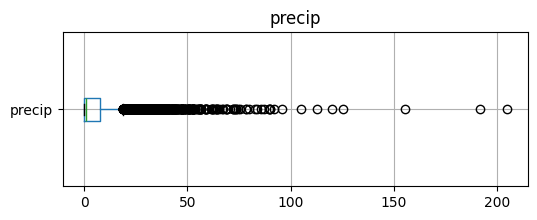

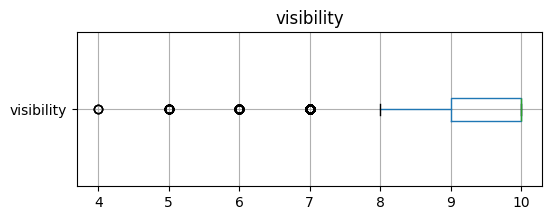

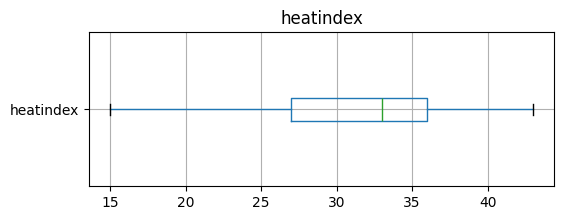

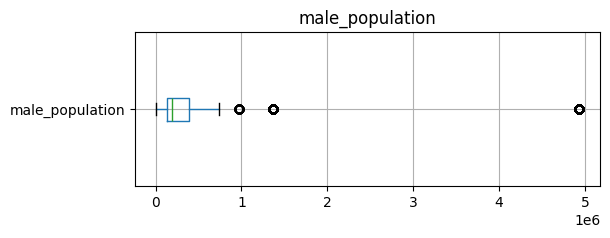

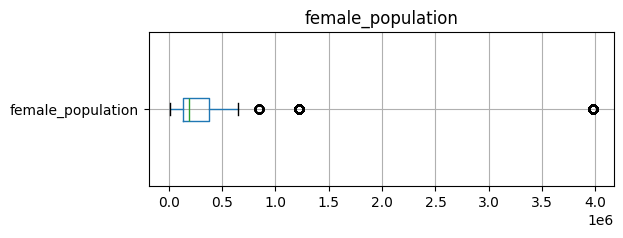

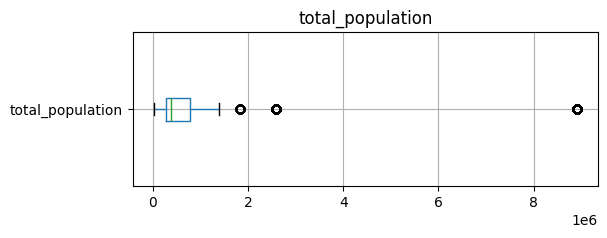

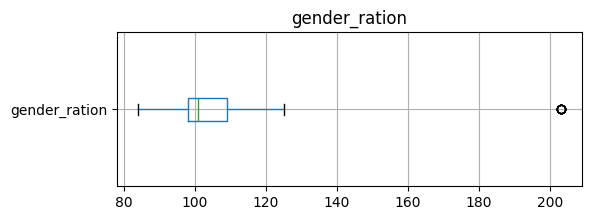

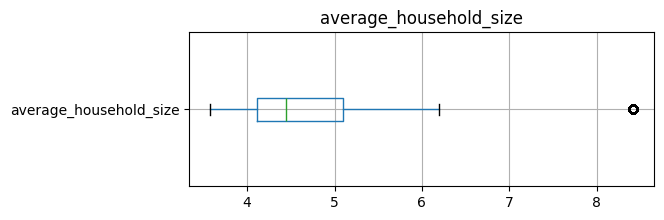

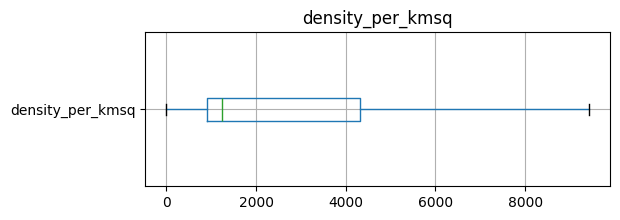

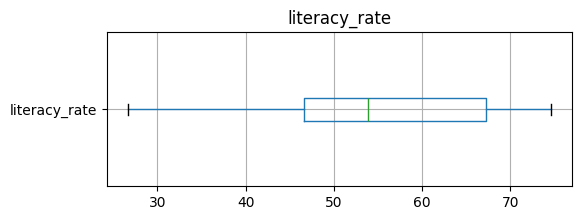

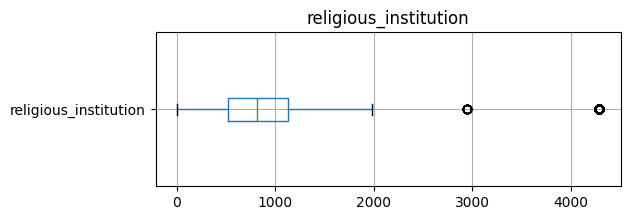

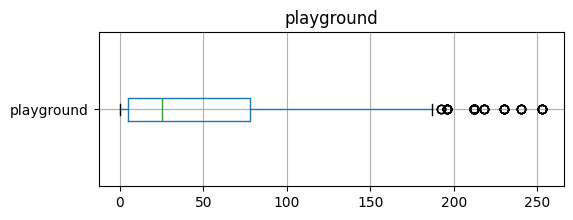

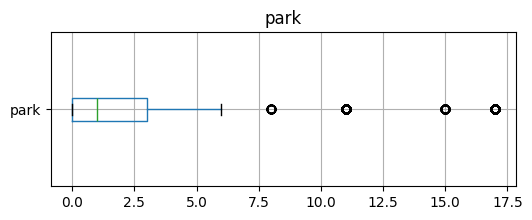

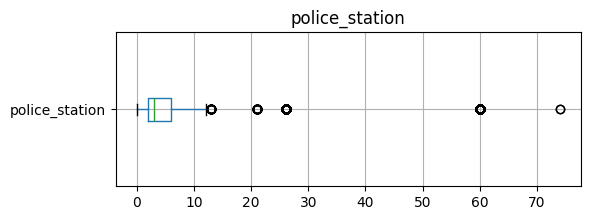

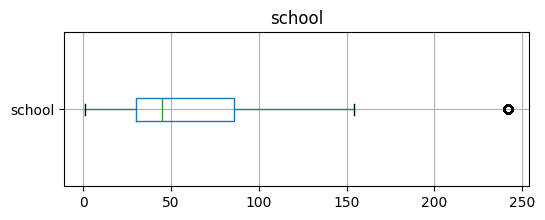

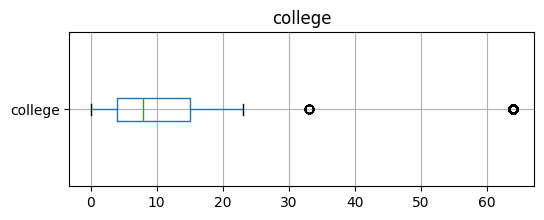

,incident_month,incident_week,weekend,precip,visibility,heatindex,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,month_sin,month_cos,week_sin,week_cos,weekday_num,weekday_sin,weekday_cos,part_of_day_num,part_sin,part_cos
min,1.0,1,0,0.0,4,15,11320,11247,22871,84,3.58,5.615431e-61,26.7,0,0,0,0.0,1,0,-1.0,-1.0,-0.999561,-0.998244,0,-0.974928,-0.900969,0,-0.951057,-0.809017
max,12.0,53,1,204.6,10,43,4931802,3974237,8906039,203,8.42,9.430000e+03,74.6,4289,253,17,74.0,242,64,1.0,1.0,0.999561,1.000000,6,0.974928,1.000000,4,0.951057,1.000000


In [1706]:
for col in num_cols:
    plt.figure(figsize=(6, 2))
    df[[col]].boxplot(vert=False)
    plt.title(col)
    plt.show()

df.select_dtypes(include="number").agg(["min", "max"])

In [1707]:
for col in num_cols:
    vals = df[col].dropna()

    Q1 = vals.quantile(0.25)
    Q3 = vals.quantile(0.75)
    IQR = Q3 - Q1

    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    outliers = vals[(vals < LB) | (vals > UB)]
    outlier_pct = (len(outliers) / len(vals)) * 100

    skewness = vals.skew()

    print(f"Column: {col}")
    print(f"  Outlier Percentage: {outlier_pct:.2f}%")
    print(f"  Skewness: {skewness:.3f}")
    print("-" * 40)


Column: precip
  Outlier Percentage: 10.44%
  Skewness: 4.344
----------------------------------------
Column: visibility
  Outlier Percentage: 4.85%
  Skewness: -2.141
----------------------------------------
Column: heatindex
  Outlier Percentage: 0.00%
  Skewness: -0.384
----------------------------------------
Column: male_population
  Outlier Percentage: 19.01%
  Skewness: 2.042
----------------------------------------
Column: female_population
  Outlier Percentage: 19.01%
  Skewness: 2.019
----------------------------------------
Column: total_population
  Outlier Percentage: 19.01%
  Skewness: 2.032
----------------------------------------
Column: gender_ration
  Outlier Percentage: 0.11%
  Skewness: 1.717
----------------------------------------
Column: average_household_size
  Outlier Percentage: 13.26%
  Skewness: 1.775
----------------------------------------
Column: density_per_kmsq
  Outlier Percentage: 0.00%
  Skewness: 1.235
----------------------------------------
Colum

Using a thumb of rule that more than 5% outliers, skewness below -0.5, or skewness above 0.5 means the distribution is non-normal.  It can be seen that most of them is not normally distributed, with the only normal distributed columns being heatindex and literacy_rate (it is only slightly above my tolerance range but i will still assume that it is normal since it does not have any outliers). Hence, these columns will be standard scaled to preserve as much variance from the column while unifying the scale of each numerical columns. Scaling is definitely beneficial for distance-based models like KMeans since the weights of each features are very dependant on their scales, so it would be better to put every numerical columns on the same scale. The rest will be robust scaled since it can still represent the middle value of the distribution well even with the existence of outliers and having non-normal properties although at the cost of lost variance as a result of scaling using the IQR and not the standard deviation.

# Missing Values Check

In [1708]:
print("The percentage of missing values of each column:")
df.isna().mean()

The percentage of missing values of each column:


incident_month            0.000000
incident_week             0.000000
incident_weekday          0.000000
weekend                   0.000000
part_of_the_day           0.000000
incident_district         0.049894
incident_division         0.000000
precip                    0.000000
visibility                0.000000
heatindex                 0.000000
season                    0.000000
male_population           0.000000
female_population         0.000000
total_population          0.000000
gender_ration             0.000000
average_household_size    0.000000
density_per_kmsq          0.000000
literacy_rate             0.049894
religious_institution     0.000000
playground                0.000000
park                      0.000000
police_station            0.000152
school                    0.000000
college                   0.000000
crime                     0.000000
month_sin                 0.000000
month_cos                 0.000000
week_sin                  0.000000
week_cos            

There are quite a few missing values. Of course, there will be no columns that will be dropped since the missing value percentage are all below 50%. I will just drop rows containing more than 50% missing values across attributes. This is so the action of imputing values won't make the data too artificial as a result of many value substitutions through a representative value. I will use KNN Imputer to impute all missing values inside numerical columns, and impute the mode for categorical columns. Because clustering tasks don't need a splitting phase and only needs to tune the k value for KMeans, I will directly impute everything after dropping the necessary rows.

In [1709]:
df = df.dropna(thresh=len(df.columns) * 0.5)

In [1710]:
print("The percentage of missing values of each column:")
df.isna().mean()

The percentage of missing values of each column:


incident_month            0.000000
incident_week             0.000000
incident_weekday          0.000000
weekend                   0.000000
part_of_the_day           0.000000
incident_district         0.049894
incident_division         0.000000
precip                    0.000000
visibility                0.000000
heatindex                 0.000000
season                    0.000000
male_population           0.000000
female_population         0.000000
total_population          0.000000
gender_ration             0.000000
average_household_size    0.000000
density_per_kmsq          0.000000
literacy_rate             0.049894
religious_institution     0.000000
playground                0.000000
park                      0.000000
police_station            0.000152
school                    0.000000
college                   0.000000
crime                     0.000000
month_sin                 0.000000
month_cos                 0.000000
week_sin                  0.000000
week_cos            

It seems to have no effect to the missing values percentage at all which indicates that all rows has less than 50% missing values, making them all reliable enough to use for training the model.

In [1711]:
mode_district = df['incident_district'].mode()[0]
df['incident_district'] = df['incident_district'].fillna(mode_district)

In [1712]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)
df[['literacy_rate', 'police_station']] = knn_imputer.fit_transform(df[['literacy_rate', 'police_station']])

In [1713]:
print("The percentage of missing values of each column:")
df.isna().mean()

The percentage of missing values of each column:


incident_month            0.0
incident_week             0.0
incident_weekday          0.0
weekend                   0.0
part_of_the_day           0.0
incident_district         0.0
incident_division         0.0
precip                    0.0
visibility                0.0
heatindex                 0.0
season                    0.0
male_population           0.0
female_population         0.0
total_population          0.0
gender_ration             0.0
average_household_size    0.0
density_per_kmsq          0.0
literacy_rate             0.0
religious_institution     0.0
playground                0.0
park                      0.0
police_station            0.0
school                    0.0
college                   0.0
crime                     0.0
month_sin                 0.0
month_cos                 0.0
week_sin                  0.0
week_cos                  0.0
weekday_num               0.0
weekday_sin               0.0
weekday_cos               0.0
part_of_day_num           0.0
part_sin  

# Duplicates Check

In [1714]:
print(f"Total Duplicates: {df.duplicated().sum()}")

Total Duplicates: 342


There are quite a lot of duplicates for this dataset, which could make the model biased to certain data points and harder to generalize on the entire dataset, so I'm going to remove all of these duplicates to ensure generalization.

In [1715]:
df = df.drop_duplicates()

In [1716]:
print(f"Total Duplicates: {df.duplicated().sum()}")

Total Duplicates: 0


All duplicates have been dropped from the dataset.

# Correlation and Association Check

## Numerical x Numerical

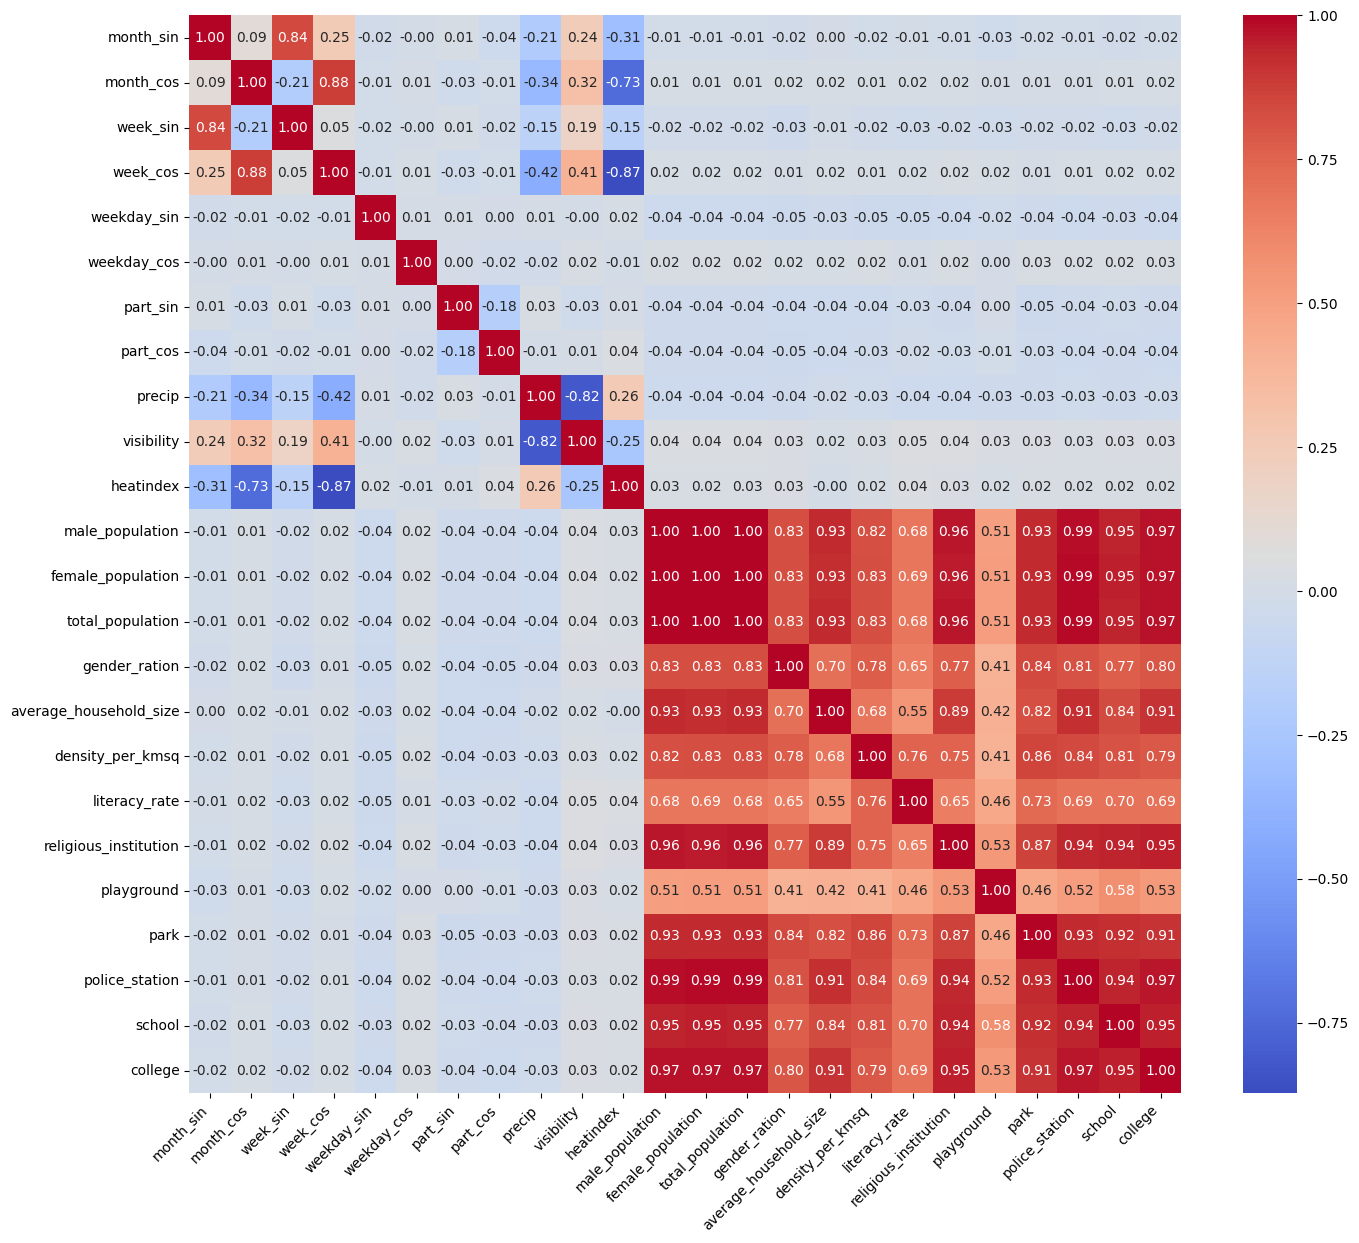

In [1717]:
num_cols = ['month_sin', 'month_cos', 'week_sin', 'week_cos', 'weekday_sin', 'weekday_cos', 'part_sin', 'part_cos', 'precip', 'visibility', 'heatindex', 'male_population', 'female_population', 'total_population', 'gender_ration', 'average_household_size', 'density_per_kmsq', 'literacy_rate', 'religious_institution', 'playground', 'park', 'police_station', 'school', 'college']

plt.figure(figsize=(16,14))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

Since I'm using a distance-based model, these extremely strong correlation between columns are bad news. These are the highlighted insights:
- **Periodic features** of month_sin with week_sin and month_cos with week_cos are very highly correlated (0.95-0.96) with each other because technically speaking they represent the same information, which is the period of happening within a year. To avoid this from destabilizing the model, I will not use all the week column (week, week_sin, and week_cos) during model training and focus more on the bigger picture, the month of incident.
- **Population features** of male_population, female_population, and total population are perfectly correlated (literally 1.00 on the correlation matrix). I will only use  total_population during model training since the gender populations have been represented by gender_ration.
- **Facillities features** of school, college, park, religious_institution, and police station also have very high correlations (0.9+). I will just aggregate these features into one total_institutions from school + college + police_station + park + religious_institution and still keep the original columns for later cluster analysis.

In [1718]:
df['total_institutions'] = df['school'] + df['college'] + df['police_station'] + df['park'] + df['religious_institution']

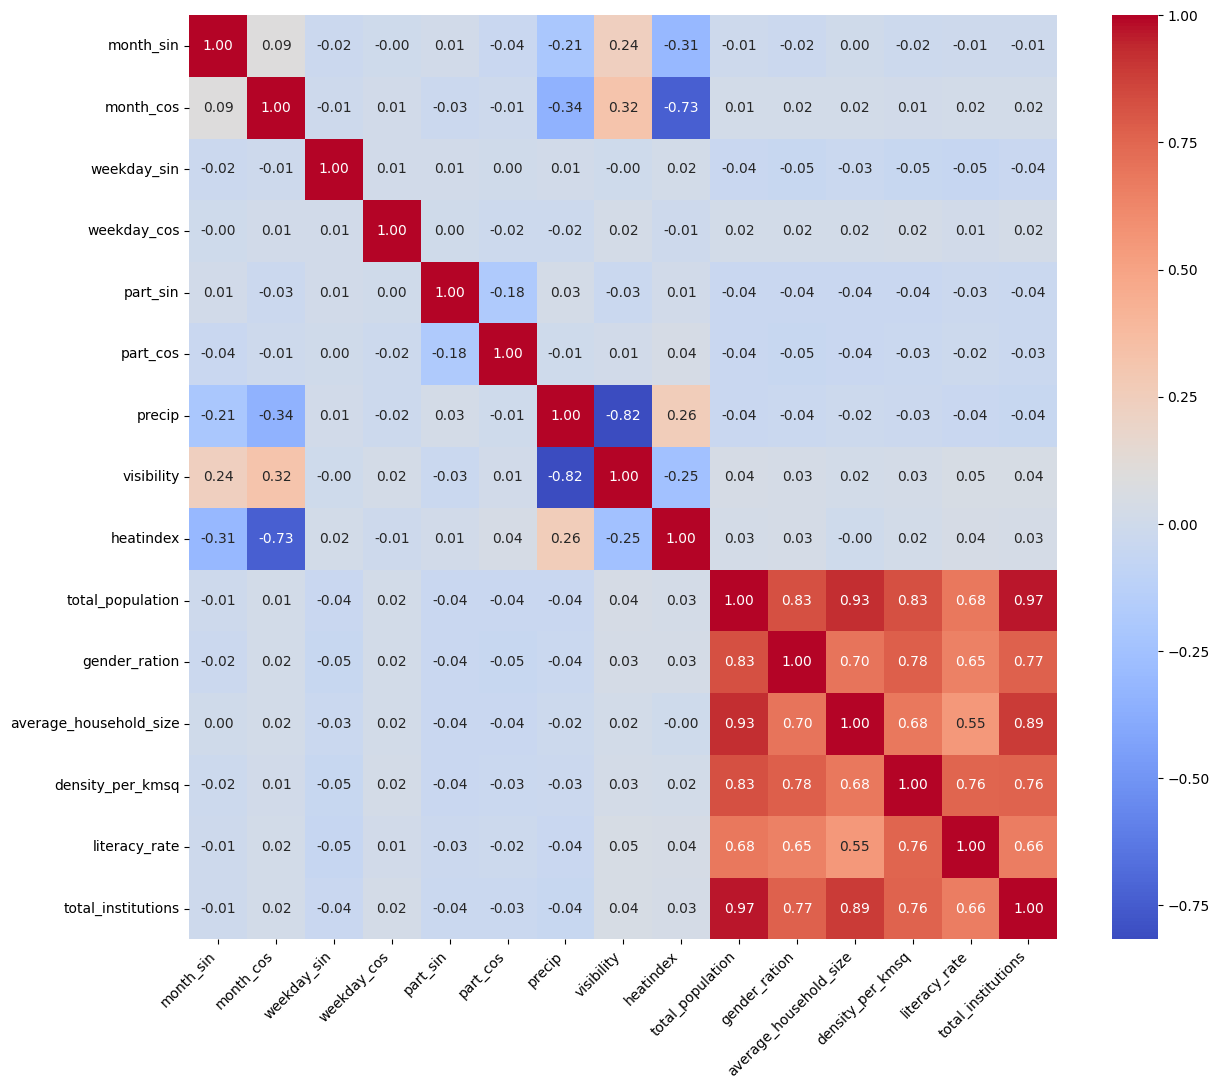

In [1719]:
num_cols = ['month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'part_sin', 'part_cos', 'precip', 'visibility', 'heatindex', 'total_population', 'gender_ration', 'average_household_size', 'density_per_kmsq', 'literacy_rate', 'total_institutions']

plt.figure(figsize=(14,12))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

Now, I am left with only two highly correlated groups, which are demografic features (total_population, gender_ration, average_household_size, literacy_rate, and total_institutions) and weather features (heat_index, visibility, and precip). I will compact each groups into one using PCA so that there won't be multicollinearity problems.

In [1720]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler
import numpy as np

# Demographic features
literacy_scaled = StandardScaler().fit_transform(df[['literacy_rate']])
demo_other_scaled = RobustScaler().fit_transform(df[['total_population', 'gender_ration', 'total_institutions']])
demo_scaled = np.hstack([literacy_scaled, demo_other_scaled, df[['average_household_size']].values])
df['demographic_PCA'] = PCA(n_components=1).fit_transform(demo_scaled)

# Weather features
heat_scaled = StandardScaler().fit_transform(df[['heatindex']])
precip_scaled = RobustScaler().fit_transform(df[['precip']])
weather_scaled = np.hstack([heat_scaled, precip_scaled, df[['visibility']].values])
df['weather_PCA'] = PCA(n_components=1).fit_transform(weather_scaled)

df.head()

,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,heatindex,season,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime,month_sin,month_cos,week_sin,week_cos,weekday_num,weekday_sin,weekday_cos,part_of_day_num,part_sin,part_cos,total_institutions,demographic_PCA,weather_PCA
0,7.0,29,wednesday,0,morning,dhaka,dhaka,6.1,10,32,rainy,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,-0.500000,-8.660254e-01,-0.292057,-0.956401,2,0.974928,-0.222521,1,0.951057,0.309017,4672.0,15.75635,-0.227770
1,1.0,2,wednesday,0,night,dhaka,dhaka,0.0,10,22,winter,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,0.500000,8.660254e-01,0.234886,0.972023,2,0.974928,-0.222521,0,0.000000,1.000000,4672.0,15.75635,-1.304024
2,1.0,4,tuesday,0,night,dhaka,dhaka,0.0,10,25,winter,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,0.500000,8.660254e-01,0.456629,0.889657,1,0.781831,0.623490,0,0.000000,1.000000,4672.0,15.75635,-1.193485
3,3.0,9,friday,1,night,dhaka,dhaka,0.0,10,30,hot,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,1.000000,6.123234e-17,0.875735,0.482792,4,-0.433884,-0.900969,0,0.000000,1.000000,4672.0,15.75635,-1.009253
4,8.0,34,thursday,0,night,dhaka,dhaka,21.9,9,38,rainy,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,-0.866025,-5.000000e-01,-0.776524,-0.630088,3,0.433884,-0.900969,0,0.000000,1.000000,4672.0,15.75635,2.275875


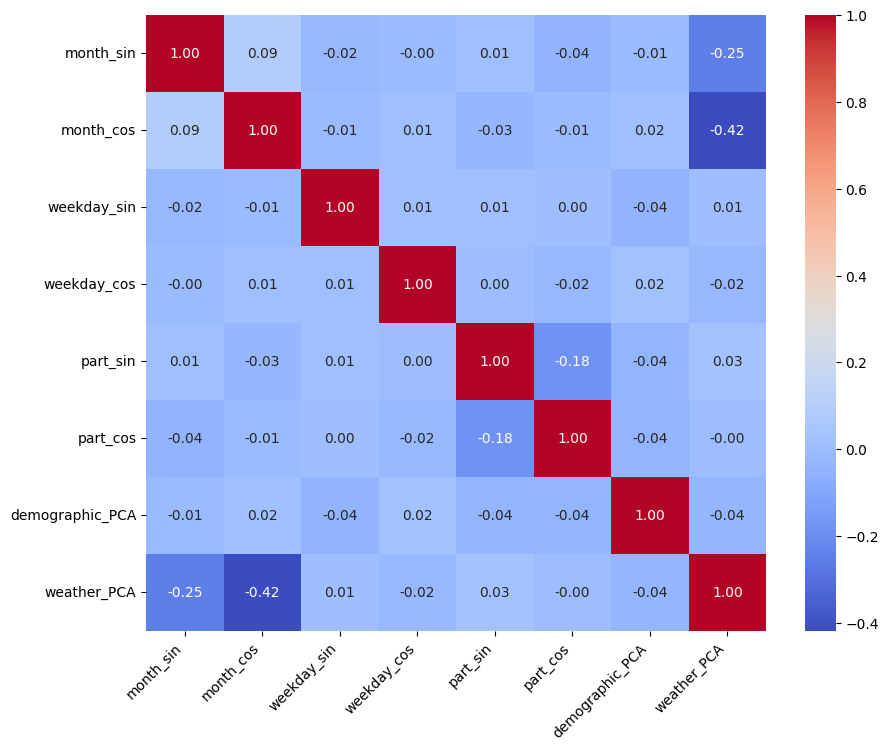

In [1721]:
num_cols = ['month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'part_sin', 'part_cos', 'demographic_PCA', 'weather_PCA']

plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

## Categorical x Categorical

In [1722]:
from scipy.stats import chi2_contingency
from itertools import combinations

def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.values.sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

cat_cols = ['weekend', 'incident_district', 'incident_division', 'season', 'crime']

In [1723]:
pairwise_results = []

for col1, col2 in combinations(cat_cols, 2):
    contingency = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    phi2 = chi2 / n
    r, k = contingency.shape
    cramers_v = (phi2 / min(k-1, r-1))**0.5
    pairwise_results.append({'Feature_1': col1, 'Feature_2': col2, 'Chi2': chi2, 'p_value': p, 'Cramers_V': cramers_v})

In [1724]:
chi_pairwise_df = pd.DataFrame(pairwise_results).sort_values('p_value').T
chi_pairwise_df

,4,6,8,9,5,7,0,2,1,3
Feature_1,incident_district,incident_district,incident_division,season,incident_district,incident_division,weekend,weekend,weekend,weekend
Feature_2,incident_division,crime,crime,crime,season,season,incident_district,season,incident_division,crime
Chi2,40657.72718,920.325405,279.070123,81.618544,200.995662,41.400672,87.810091,2.89919,7.965306,4.224943
p_value,0.0,0.0,0.0,0.0,0.000025,0.000484,0.021159,0.234665,0.436866,0.517505
Cramers_V,0.903052,0.171859,0.094636,0.080922,0.126989,0.057633,0.118702,0.021569,0.035751,0.026037


H0: The two variables are independent (no relationship)  
H1: The two variables are related  

The result of the chi-squared test for almost all categorical column pairs, excluding the last three pairs, shows that each one of them has p-value lower than 0.05, meaning that the null hypothesis is rejected and there's sufficient evidence to conclude that all categorical column pair are related to each other. Meanwhile, the last three pairs have p-value bigger than 0.05, meaning that the null hypothesis can not be rejected and hence keeping the same hypothesis, which is that the two variables are independent or no relationship at all.

In [1725]:
cramers_pairwise_df = pd.DataFrame(pairwise_results).sort_values('Cramers_V', ascending=False).T
cramers_pairwise_df

,4,6,5,0,8,9,7,1,3,2
Feature_1,incident_district,incident_district,incident_district,weekend,incident_division,season,incident_division,weekend,weekend,weekend
Feature_2,incident_division,crime,season,incident_district,crime,crime,season,incident_division,crime,season
Chi2,40657.72718,920.325405,200.995662,87.810091,279.070123,81.618544,41.400672,7.965306,4.224943,2.89919
p_value,0.0,0.0,0.000025,0.021159,0.0,0.0,0.000484,0.436866,0.517505,0.234665
Cramers_V,0.903052,0.171859,0.126989,0.118702,0.094636,0.080922,0.057633,0.035751,0.026037,0.021569


There's one multicollinearity issue with intercategorical columns where incident_district has a strong association with incident_division at a whopping 0.9369. Other categorical column pairs only barely scratched the 0.20 mark, which highlights the severity of that multicollinear pair. And so, I would need to sacrifice either one of those two columns so that the model wouldn't get chaotic due to this absurdly high association.

In [1726]:
pd.set_option("display.max_rows", None)
df['incident_district'].value_counts(normalize=True)

incident_district
dhaka              0.220635
chattogram         0.072047
mymensingh         0.038671
jashore            0.037227
dinajpur           0.029685
narayanganj        0.025513
gazipur            0.025353
bogura             0.025032
pabna              0.024551
tangail            0.022786
sylhet             0.022465
rajshahi           0.019737
brahmanbaria       0.018453
rangpur            0.017330
habiganj           0.016367
patuakhali         0.015725
jamalpur           0.015565
moulvibazar        0.015244
pirojpur           0.014602
lalmonirhat        0.014281
faridpur           0.013639
thakurgaon         0.012997
joypurhat          0.012195
barisal            0.012035
jhenaidah          0.011714
noakhali           0.011072
sirajganj          0.010911
manikganj          0.010751
gaibandha          0.010591
kushtia            0.010591
bandarban          0.010591
coxsbazar          0.010109
chapainawabganj    0.009788
nilphamari         0.009146
comilla            0.008825
ba

In [1727]:
df['incident_division'].value_counts(normalize=True)

incident_division
dhaka         0.309852
chattogram    0.161585
rajshahi      0.117779
rangpur       0.108472
khulna        0.106868
mymensingh    0.069320
sylhet        0.063222
barisal       0.062259
gazipur       0.000642
Name: proportion, dtype: float64

incident_division has less categories than incident_district and still contains similar information (as seen from their high association with each other). So, I decided to only use incident_division for training the KMeans model. Having less categories and pretty much the same information leads to better generalization for machine learning models in general because they have less features they need to learn and tune during training.

# Numerical x Categorical

In [1728]:
from scipy.stats import f_oneway

num_cols = ['month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'part_sin', 'part_cos', 'demographic_PCA', 'weather_PCA']
cat_cols = ['weekend', 'incident_division', 'season', 'crime']

In [1729]:
results = []

for cat_col in cat_cols:
    for num_col in num_cols:
        groups = [df.loc[df[cat_col] == cat, num_col].dropna() for cat in df[cat_col].dropna().unique()]
        if len(groups) > 1 and all(len(g) > 1 for g in groups):
            f_stat, p_value = f_oneway(*groups)
            all_vals = np.concatenate(groups)
            grand_mean = all_vals.mean()
            ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
            ss_total = ((all_vals - grand_mean) ** 2).sum()
            eta_squared = ss_between / ss_total
            results.append({"Categorical": cat_col, "Numerical": num_col, "p_value": p_value, "eta_squared": eta_squared})
    
anova_df = pd.DataFrame(results)

In [1730]:
print("ANOVA Test sorted by p-values:")
anova_df.sort_values("p_value").T

ANOVA Test sorted by p-values:


,3,2,14,16,17,23,28,29,30,24,25,12,15,13,4,8,31,10,1,0,22,20,21,27,9,18,19,5,7,11,26,6
Categorical,weekend,weekend,incident_division,season,season,season,crime,crime,crime,crime,crime,incident_division,incident_division,incident_division,weekend,incident_division,crime,incident_division,weekend,weekend,season,season,season,crime,incident_division,season,season,weekend,weekend,incident_division,crime,weekend
Numerical,weekday_cos,weekday_sin,demographic_PCA,month_sin,month_cos,weather_PCA,part_sin,part_cos,demographic_PCA,month_sin,month_cos,part_sin,weather_PCA,part_cos,part_sin,month_sin,weather_PCA,weekday_sin,month_cos,month_sin,demographic_PCA,part_sin,part_cos,weekday_cos,month_cos,weekday_sin,weekday_cos,part_cos,weather_PCA,weekday_cos,weekday_sin,demographic_PCA
p_value,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001254,0.001437,0.001611,0.055816,0.119233,0.12716,0.17912,0.204062,0.213934,0.227993,0.260675,0.358864,0.541962,0.551708,0.581246,0.584655,0.67721,0.832482,0.934025
eta_squared,0.243536,0.409334,0.359931,0.556967,0.537175,0.215891,0.074049,0.054279,0.025348,0.012983,0.008561,0.008845,0.007501,0.004095,0.001629,0.003993,0.00173,0.002052,0.000373,0.00029,0.00051,0.000495,0.000475,0.001043,0.001414,0.000197,0.000191,0.000049,0.000048,0.00092,0.00034,0.000001


In [1731]:
percentage = (anova_df["p_value"] > 0.05).mean() * 100
print(f"Total numerical-categorical pair that has p value > 0.05: {percentage:.2f}%")

Total numerical-categorical pair that has p value > 0.05: 50.00%


H0: any observed differences in sample means are due to random variation  
H1: at least one sample means difference exist  

Around half of those numerical and categorical column pairs have insufficient evidence that at least one sample means difference exist, so for these ones the null hypothesis is not rejected. Meanwhile, the other half has sufficient evidence, hence the null hypothesis is rejected and the hypothesis is now switched to at least one sample means difference exist.

In [1732]:
print("ANOVA Test sorted by eta_squared (filtered to only having p <= 0.05):")
anova_df.sort_values("eta_squared", ascending=False).loc[anova_df["p_value"] <= 0.05].T

ANOVA Test sorted by eta_squared (filtered to only having p <= 0.05):


,16,17,2,14,3,23,28,29,30,24,12,25,15,13,8,4
Categorical,season,season,weekend,incident_division,weekend,season,crime,crime,crime,crime,incident_division,crime,incident_division,incident_division,incident_division,weekend
Numerical,month_sin,month_cos,weekday_sin,demographic_PCA,weekday_cos,weather_PCA,part_sin,part_cos,demographic_PCA,month_sin,part_sin,month_cos,weather_PCA,part_cos,month_sin,part_sin
p_value,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001254,0.001611,0.001437
eta_squared,0.556967,0.537175,0.409334,0.359931,0.243536,0.215891,0.074049,0.054279,0.025348,0.012983,0.008845,0.008561,0.007501,0.004095,0.003993,0.001629


A high eta_squared here, unlike Pearson correlation and Cramer's V, does not mean that two features are redundant. While Pearson correlation measures linear relationships between numerical features and high values suggest overlapping information, and Cramér's V measures association between categorical features where high values imply strong dependence, eta_squared instead quantifies how much variance in a numerical feature is explained by a categorical feature. A high eta_squared therefore signals that the categorical feature carries valuable information, creating natural separation in the numerical feature space, which is especially useful for clustering algorithms like KMeans. Low eta_squared, on the other hand, contributes little to cluster separation and may be considered noise. However, all of them will still be kept because even highly correlated or strongly associated features can provide complementary signals in a distance-based algorithm like KMeans, and dropping them could remove subtle but meaningful distinctions that help form more accurate and interpretable clusters.

# Build Pipeline

In [1733]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [1734]:
df.head(5)

,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,heatindex,season,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime,month_sin,month_cos,week_sin,week_cos,weekday_num,weekday_sin,weekday_cos,part_of_day_num,part_sin,part_cos,total_institutions,demographic_PCA,weather_PCA
0,7.0,29,wednesday,0,morning,dhaka,dhaka,6.1,10,32,rainy,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,-0.500000,-8.660254e-01,-0.292057,-0.956401,2,0.974928,-0.222521,1,0.951057,0.309017,4672.0,15.75635,-0.227770
1,1.0,2,wednesday,0,night,dhaka,dhaka,0.0,10,22,winter,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,0.500000,8.660254e-01,0.234886,0.972023,2,0.974928,-0.222521,0,0.000000,1.000000,4672.0,15.75635,-1.304024
2,1.0,4,tuesday,0,night,dhaka,dhaka,0.0,10,25,winter,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,0.500000,8.660254e-01,0.456629,0.889657,1,0.781831,0.623490,0,0.000000,1.000000,4672.0,15.75635,-1.193485
3,3.0,9,friday,1,night,dhaka,dhaka,0.0,10,30,hot,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,1.000000,6.123234e-17,0.875735,0.482792,4,-0.433884,-0.900969,0,0.000000,1.000000,4672.0,15.75635,-1.009253
4,8.0,34,thursday,0,night,dhaka,dhaka,21.9,9,38,rainy,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,-0.866025,-5.000000e-01,-0.776524,-0.630088,3,0.433884,-0.900969,0,0.000000,1.000000,4672.0,15.75635,2.275875


In [1735]:
pass_through = ['month_sin','month_cos','weekday_sin','weekday_cos', 'part_sin','part_cos','demographic_PCA','weather_PCA','weekend']
cat_ohe = ['incident_division','season','crime']

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_ohe),
    ('pass', 'passthrough', pass_through)
])

X_processed = preprocessor.fit_transform(df)

#### B. Train K-Means and tune it based on a minimum of two metrics. Afterward, visualize the final clusters! 

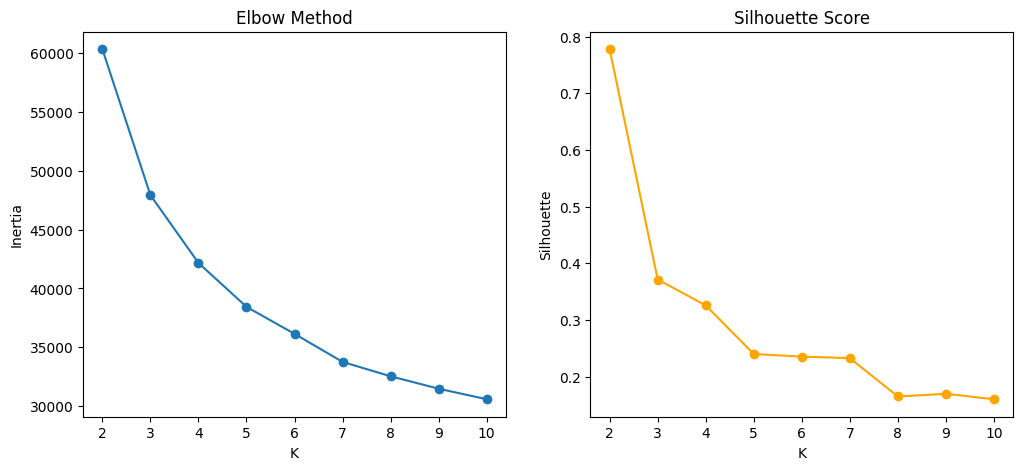

In [1736]:
inertia, sil_scores = [], []
K_range = range(2,11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=1, n_init=10)
    km.fit(X_processed)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_processed, km.labels_))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K_range, inertia, 'o-'); plt.xlabel('K'); plt.ylabel('Inertia'); plt.title('Elbow Method')
plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, 'o-', color='orange'); plt.xlabel('K'); plt.ylabel('Silhouette'); plt.title('Silhouette Score')
plt.show()

From the elbow plot, there is a clear change in slope at K = 3, where the reduction in inertia begins to slow down, indicating diminishing returns from adding more clusters. At the same time, the silhouette score at K = 3 remains relatively high compared to larger values of K, showing that clusters are still reasonably well separated. While the silhouette score is highest at K = 2, this typically reflects an overly coarse partition. Therefore, K = 3 provides the best balance between minimizing within-cluster variance and maintaining meaningful cluster separation, making it the most appropriate choice based on both metrics. 

In [1742]:
kmeans_final = KMeans(n_clusters=3, random_state=1, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_processed)
df['cluster'] = cluster_labels

In [1743]:
df.head(5)

,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,heatindex,season,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime,month_sin,month_cos,week_sin,week_cos,weekday_num,weekday_sin,weekday_cos,part_of_day_num,part_sin,part_cos,total_institutions,demographic_PCA,weather_PCA,cluster
0,7.0,29,wednesday,0,morning,dhaka,dhaka,6.1,10,32,rainy,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,-0.500000,-8.660254e-01,-0.292057,-0.956401,2,0.974928,-0.222521,1,0.951057,0.309017,4672.0,15.75635,-0.227770,1
1,1.0,2,wednesday,0,night,dhaka,dhaka,0.0,10,22,winter,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,0.500000,8.660254e-01,0.234886,0.972023,2,0.974928,-0.222521,0,0.000000,1.000000,4672.0,15.75635,-1.304024,1
2,1.0,4,tuesday,0,night,dhaka,dhaka,0.0,10,25,winter,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,0.500000,8.660254e-01,0.456629,0.889657,1,0.781831,0.623490,0,0.000000,1.000000,4672.0,15.75635,-1.193485,1
3,3.0,9,friday,1,night,dhaka,dhaka,0.0,10,30,hot,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,1.000000,6.123234e-17,0.875735,0.482792,4,-0.433884,-0.900969,0,0.000000,1.000000,4672.0,15.75635,-1.009253,1
4,8.0,34,thursday,0,night,dhaka,dhaka,21.9,9,38,rainy,4931802,3974237,8906039,125,8.42,9430.0,74.6,4289,99,17,60.0,242,64,murder,-0.866025,-5.000000e-01,-0.776524,-0.630088,3,0.433884,-0.900969,0,0.000000,1.000000,4672.0,15.75635,2.275875,1


In [1744]:
df['cluster'].value_counts()

cluster
0    4503
2     906
1     823
Name: count, dtype: int64

In [1745]:
cat_cols = ['incident_month', 'incident_weekday', 'weekend', 'part_of_the_day', 'incident_division', 'season', 'crime']

for col in cat_cols:
    print(f"\n=== Cluster vs {col} ===")
    display(pd.crosstab(df['cluster'], df[col], normalize='index'))


=== Cluster vs incident_month ===


incident_month,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
cluster,,,,,,,,,,,,
0,0.092161,0.088386,0.093715,0.089052,0.085054,0.057739,0.048190,0.170997,0.062181,0.081279,0.067955,0.063291
1,0.088700,0.074119,0.078979,0.074119,0.065614,0.069259,0.083840,0.196841,0.086270,0.070474,0.052248,0.059538
2,0.000000,0.000000,0.003311,0.045254,0.103753,0.152318,0.229581,0.293598,0.114790,0.050773,0.006623,0.000000



=== Cluster vs incident_weekday ===


incident_weekday,friday,monday,saturday,sunday,thursday,tuesday,wednesday
cluster,,,,,,,
0,0.133467,0.149012,0.141683,0.123473,0.142794,0.158561,0.151010
1,0.140948,0.161604,0.132442,0.170109,0.144593,0.137303,0.113001
2,0.141280,0.129139,0.122517,0.145695,0.155629,0.145695,0.160044



=== Cluster vs weekend ===


...

incident_division,barisal,chattogram,dhaka,gazipur,khulna,mymensingh,rajshahi,rangpur,sylhet
cluster,,,,,,,,,
0,0.075061,0.179436,0.218965,0.000888,0.124806,0.077726,0.133911,0.11992,0.069287
1,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
2,0.055188,0.219647,0.134658,0.000000,0.114790,0.090508,0.144592,0.15011,0.090508



=== Cluster vs season ===


season,hot,rainy,winter
cluster,,,
0,0.297357,0.351988,0.350655
1,0.249089,0.441069,0.309842
2,0.174393,0.818985,0.006623



=== Cluster vs crime ===


crime,assault,bodyfound,kidnap,murder,rape,robbery
cluster,,,,,,
0,0.166111,0.232956,0.101932,0.241395,0.179880,0.077726
1,0.178615,0.278250,0.077764,0.143378,0.138518,0.183475
2,0.171082,0.207506,0.096026,0.249448,0.211921,0.064018


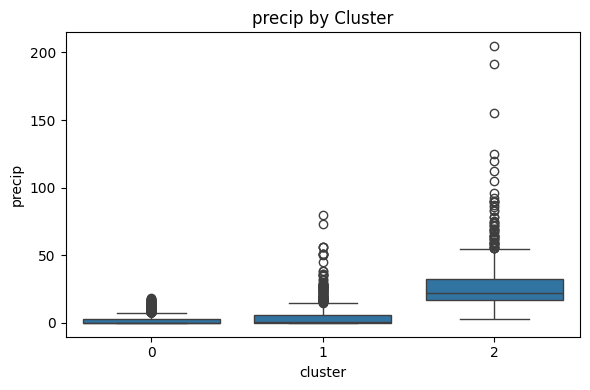

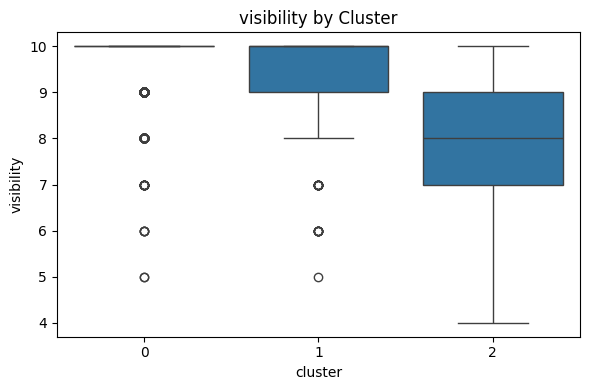

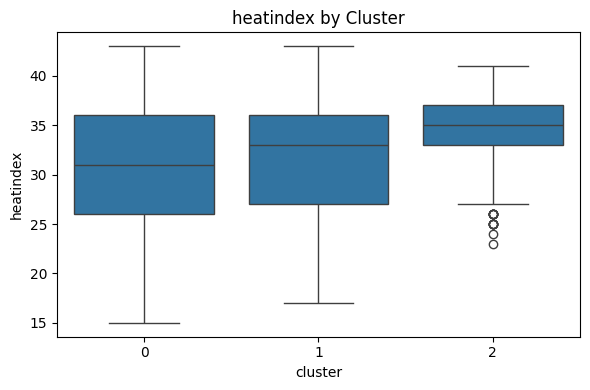

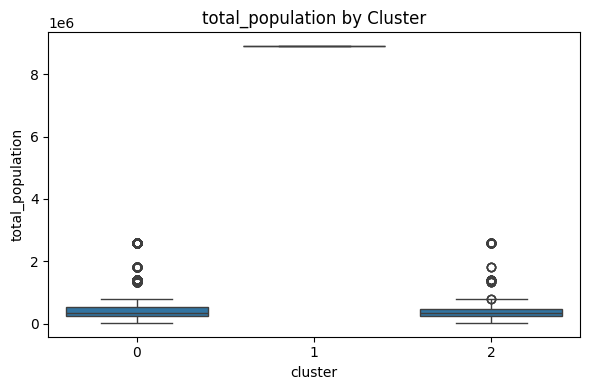

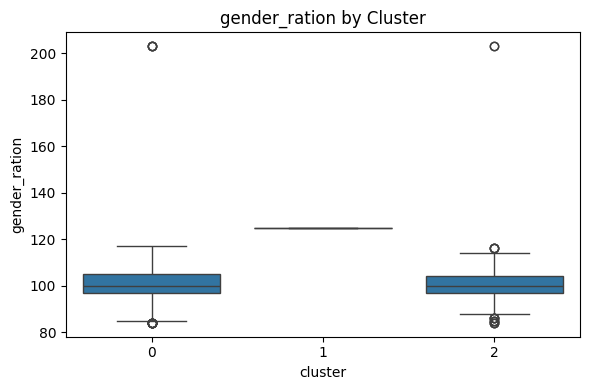

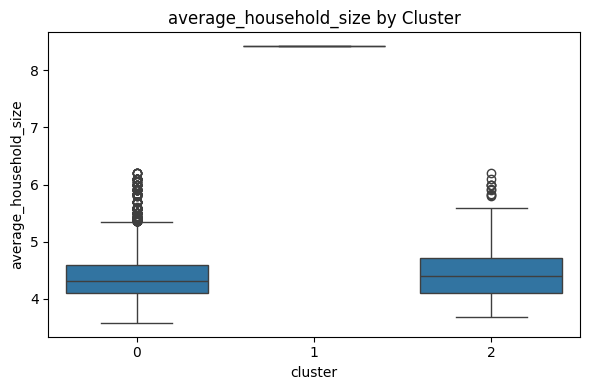

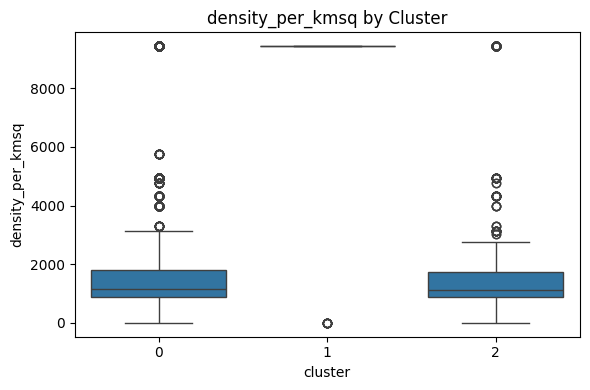

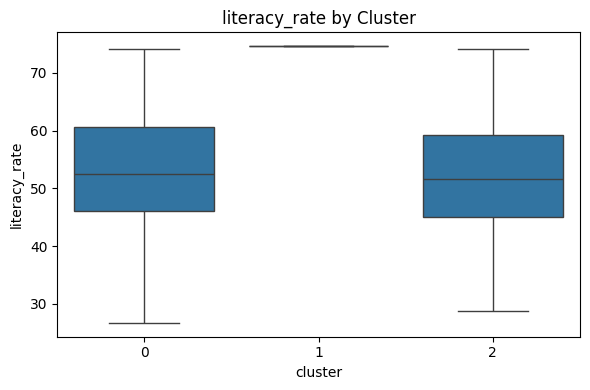

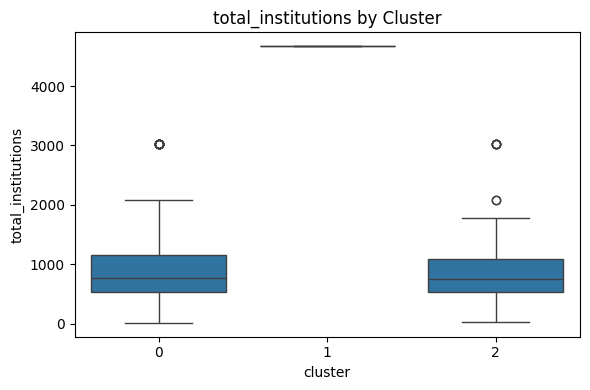

In [1746]:
num_cols = ['precip', 'visibility', 'heatindex', 'total_population', 'gender_ration', 'average_household_size', 'density_per_kmsq', 'literacy_rate', 'total_institutions']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='cluster', y=col, data=df)
    plt.title(f'{col} by Cluster')
    plt.tight_layout()
    plt.show()

#### C. Profile each cluster to understand crime characteristics! 

The three clusters can be profiled as the following.
- **Cluster 0, Seasonal Low-Pressure Community Crime**. Cluster 0 is characterized by winter to rainy dominant incidents (makes up around 70% of their proportion in total) and their peak activity is usually done somewhere near the end or the start of the year. They become inactive during the middle of the year as shown by relatively lower proportions of cluster 0 during June-July. Crimes occur across multiple divisions (Chattogram, Dhaka, Rajshahi, Rangpur, Khulna), indicating geographically dispersed areas. The socio-demographic features (total_institutions, literacy_rate, density_per_dmsq, average_household_size, gender_ration, and total_population) all are mirrors to each other, suggesting moderately populated, well-distributed community settings rather than dense urban centers. Combined with low precipitation and lower heat stress, crime in this cluster appears driven by routine social interaction and opportunity, not environmental or structural pressure, reflecting everyday community-level offenses.
- **Cluster 1, Urban Structural Year-Round Crime**. Cluster 1 is entirely Dhaka-centric (reaching 100%), with incidents occurring consistently throughout the year and a mild peak in August. The balanced seasonal distribution, alongside moderate rainfall and heat, indicates crimes that are quite independent of climate, instead driven by high population density, urban infrastructure concentration, and continuous human activity. The alignment of population, literacy, and number of institutions reinforces this cluster as dense metropolitan environments, where crime is structurally embedded in daily urban life.
- **Cluster 2, Climate-Driven Rainy-Season Crime**. Cluster 2 is strongly dominated by the rainy season (roughly 81%), with a sharp concentration between May and September, peaking in August. Spatially, incidents are widely distributed across divisions, indicating dispersed regions rather than a single metropolitan core. Despite sharing similar socio-demographic and institutional distributions with each other, the defining factor here is environmental stress-high precipitation, heat, and reduced visibility. These conditions likely amplify situational and stress-induced crimes, such as domestic disputes, accidents, or infrastructure-related incidents, suggesting that crime in this cluster is reactive to climatic disruption rather than population structure alone.

#### D. Produce a concise presentation video covering your analysis highlights!

Video Link: https://youtu.be/JgKqvAaHjfE